# Veridian — Phase 1 EDA: Olist Brazilian E-Commerce

**Goal (Phase 1, Data Analyst):** load all Olist CSVs, join them into a single
*order-level* table, profile data quality, and chart the two relationships that
motivate the product — **actual vs. estimated delivery time** and the
**review-score distribution**.

The order-level table has **one row per order** and is the foundation for the
feature table built in Phase 2. Nothing here trains a model — that is Phase 3.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)

# Resolve the repo root so the notebook works whether it is run from the repo
# root or from notebooks/ (Jupyter sets cwd to the notebook's folder).
ROOT = Path.cwd()
while not (ROOT / "CLAUDE.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RAW = ROOT / "data/raw"
PROC = ROOT / "data/processed"
FIG = ROOT / "notebooks/figures"
PROC.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


## 1. Load the raw CSVs

In [2]:
orders = pd.read_csv(RAW / "olist_orders_dataset.csv")
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
items = pd.read_csv(RAW / "olist_order_items_dataset.csv")
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv")
products = pd.read_csv(RAW / "olist_products_dataset.csv")
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv")
geolocation = pd.read_csv(RAW / "olist_geolocation_dataset.csv")
cat_tx = pd.read_csv(RAW / "product_category_name_translation.csv")

tables = {
    "orders": orders, "customers": customers, "items": items,
    "payments": payments, "reviews": reviews, "products": products,
    "sellers": sellers, "geolocation": geolocation, "cat_tx": cat_tx,
}
pd.DataFrame(
    {"rows": [len(t) for t in tables.values()],
     "cols": [t.shape[1] for t in tables.values()]},
    index=tables.keys(),
)

,rows,cols
orders,99441,8
customers,99441,5
items,112650,7
payments,103886,5
reviews,99224,7
products,32951,9
sellers,3095,4
geolocation,1000163,5
cat_tx,71,2


## 2. Parse timestamps

The five order timestamps are read as strings; convert them to datetimes so we
can compute delivery durations. `errors="coerce"` turns unparseable/empty values
into `NaT` (notably absent delivery dates for orders that never arrived).

In [3]:
order_date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for c in order_date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"], errors="coerce")
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"], errors="coerce")
orders[order_date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 3. Collapse the many-to-one tables to one row per order

`order_items` and `order_payments` have several rows per order, and `reviews`
occasionally has duplicates. We aggregate each to a single row keyed on
`order_id` so the final join cannot fan out the order count.

In [4]:
# Attach English category names to products, then to item lines.
products = products.merge(cat_tx, on="product_category_name", how="left")
items_prod = items.merge(
    products[["product_id", "product_category_name", "product_category_name_english"]],
    on="product_id", how="left",
)

# One row per order: counts + money totals.
items_agg = items_prod.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    n_sellers=("seller_id", "nunique"),
    n_products=("product_id", "nunique"),
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
).reset_index()

# Dominant (modal) category per order.
cat_mode = (
    items_prod.dropna(subset=["product_category_name_english"])
    .groupby("order_id")["product_category_name_english"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
    .reset_index().rename(columns={"product_category_name_english": "main_category"})
)
items_agg = items_agg.merge(cat_mode, on="order_id", how="left")
items_agg.head()

,order_id,n_items,n_sellers,n_products,total_price,total_freight,main_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,garden_tools


In [5]:
# Payments: totals + the single highest-value payment method per order.
pay_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    n_payments=("payment_sequential", "count"),
    max_installments=("payment_installments", "max"),
).reset_index()
pay_type = (
    payments.sort_values("payment_value", ascending=False)
    .drop_duplicates("order_id")[["order_id", "payment_type"]]
    .rename(columns={"payment_type": "primary_payment_type"})
)
pay_agg = pay_agg.merge(pay_type, on="order_id", how="left")

# Reviews: keep the latest-answered review per order.
rev_one = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates("order_id", keep="last")[["order_id", "review_score", "review_creation_date"]]
)
print(f"reviews: {len(reviews):,} rows -> {len(rev_one):,} unique-order reviews")
print(f"payments: {len(payments):,} rows -> {len(pay_agg):,} order rows")
print(f"items: {len(items):,} lines -> {len(items_agg):,} order rows")

reviews: 99,224 rows -> 98,673 unique-order reviews
payments: 103,886 rows -> 99,440 order rows
items: 112,650 lines -> 98,666 order rows


## 4. Join into the order-level table

In [6]:
df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(pay_agg, on="order_id", how="left")
    .merge(rev_one, on="order_id", how="left")
)
assert len(df) == len(orders), "join fanned out the order count!"
print(f"order-level table: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head(3)

order-level table: 99,441 rows x 24 cols


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,n_items,n_sellers,n_products,total_price,total_freight,main_category,total_payment_value,n_payments,max_installments,primary_payment_type,review_score,review_creation_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,housewares,38.71,3.0,1.0,voucher,4.0,2017-10-11
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,perfumery,141.46,1.0,1.0,boleto,4.0,2018-08-08
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,auto,179.12,1.0,3.0,credit_card,5.0,2018-08-18


## 5. Derived delivery metrics

The product question is *"will this order go wrong?"* The first proxy is delivery
timing. We measure everything in **days** from purchase.

- `actual_delivery_days` — purchase → customer delivery
- `estimated_delivery_days` — purchase → the estimate shown to the customer
- `delivery_vs_estimate_days` — delivered minus estimated (**positive = late**)
- `is_late` — delivered after the estimate

In [7]:
day = np.timedelta64(1, "D")
df["actual_delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]) / day
df["estimated_delivery_days"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]) / day
df["delivery_vs_estimate_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]) / day
df["is_late"] = df["delivery_vs_estimate_days"] > 0

# Persist the joined table for Phase 2 (gitignored; derived artifact).
df.to_csv(PROC / "orders_order_level.csv", index=False)
df[["actual_delivery_days", "estimated_delivery_days", "delivery_vs_estimate_days"]].describe().round(2)

,actual_delivery_days,estimated_delivery_days,delivery_vs_estimate_days
count,96476.00,99441.00,96476.00
mean,12.56,23.77,-11.18
std,9.55,8.83,10.19
min,0.53,1.65,-146.02
25%,6.77,18.33,-16.24
50%,10.22,23.24,-11.95
75%,15.72,28.42,-6.39
max,209.63,155.14,188.98


## 6. Data-quality profile

In [8]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
}).sort_values("pct_missing", ascending=False)
profile

,dtype,n_missing,pct_missing,n_unique
delivery_vs_estimate_days,float64,2965,2.98,91915
order_delivered_customer_date,datetime64[us],2965,2.98,95664
actual_delivery_days,float64,2965,2.98,93809
main_category,str,2185,2.20,71
order_delivered_carrier_date,datetime64[us],1783,1.79,81018
n_items,float64,775,0.78,17
total_freight,float64,775,0.78,7970
total_price,float64,775,0.78,7761
n_sellers,float64,775,0.78,5
n_products,float64,775,0.78,8


In [9]:
# Numeric ranges — sanity-check for impossible values (e.g. negative days/prices).
num_cols = [
    "n_items", "total_price", "total_freight", "total_payment_value",
    "max_installments", "actual_delivery_days", "estimated_delivery_days",
    "delivery_vs_estimate_days", "review_score",
]
df[num_cols].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
n_items,98666.0,1.14,0.54,1.00,1.00,1.00,1.00,21.00
total_price,98666.0,137.75,210.65,0.85,45.90,86.90,149.90,13440.00
total_freight,98666.0,22.82,21.65,0.00,13.85,17.17,24.04,1794.96
total_payment_value,99440.0,160.99,221.95,0.00,62.01,105.29,176.97,13664.08
max_installments,99440.0,2.93,2.72,0.00,1.00,2.00,4.00,24.00
actual_delivery_days,96476.0,12.56,9.55,0.53,6.77,10.22,15.72,209.63
estimated_delivery_days,99441.0,23.77,8.83,1.65,18.33,23.24,28.42,155.14
delivery_vs_estimate_days,96476.0,-11.18,10.19,-146.02,-16.24,-11.95,-6.39,188.98
review_score,98673.0,4.09,1.35,1.00,4.00,5.00,5.00,5.00


In [10]:
print("order_status distribution:")
print(df["order_status"].value_counts().to_string())
print(f"\nNegative actual_delivery_days (data errors): {(df['actual_delivery_days'] < 0).sum()}")
print(f"Orders with no delivery date: {df['order_delivered_customer_date'].isna().sum()}")
print(f"Orders with no review:        {df['review_score'].isna().sum()}")

order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Negative actual_delivery_days (data errors): 0
Orders with no delivery date: 2965
Orders with no review:        768


## 7. Chart — actual vs. estimated delivery time

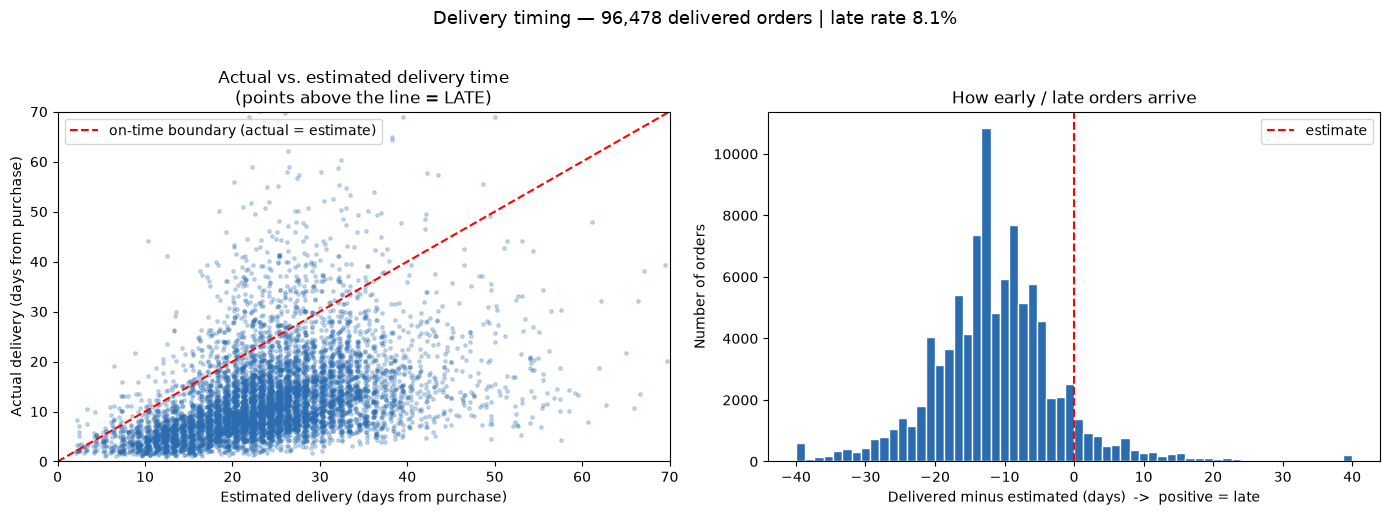

Median actual: 10.2 d | median estimated: 23.2 d | late rate: 8.1%


In [11]:
delivered = df[df["order_status"] == "delivered"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) actual vs estimated scatter with the y = x parity line.
s = delivered.sample(8000, random_state=42)
axes[0].scatter(s["estimated_delivery_days"], s["actual_delivery_days"],
                s=6, alpha=0.25, color="#2b6cb0")
lim = 70
axes[0].plot([0, lim], [0, lim], "r--", lw=1.5, label="on-time boundary (actual = estimate)")
axes[0].set(xlim=(0, lim), ylim=(0, lim),
            xlabel="Estimated delivery (days from purchase)",
            ylabel="Actual delivery (days from purchase)",
            title="Actual vs. estimated delivery time\n(points above the line = LATE)")
axes[0].legend(loc="upper left")

# (b) distribution of (actual - estimated); >0 is late.
diff = delivered["delivery_vs_estimate_days"].dropna()
axes[1].hist(diff.clip(-40, 40), bins=60, color="#2b6cb0", edgecolor="white")
axes[1].axvline(0, color="red", ls="--", lw=1.5, label="estimate")
axes[1].set(xlabel="Delivered minus estimated (days)  ->  positive = late",
            ylabel="Number of orders",
            title="How early / late orders arrive")
axes[1].legend()

late_rate = delivered["is_late"].mean() * 100
fig.suptitle(f"Delivery timing — {len(delivered):,} delivered orders | late rate {late_rate:.1f}%",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG / "delivery_actual_vs_estimated.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"Median actual: {delivered['actual_delivery_days'].median():.1f} d | "
      f"median estimated: {delivered['estimated_delivery_days'].median():.1f} d | "
      f"late rate: {late_rate:.1f}%")

## 8. Chart — review-score distribution

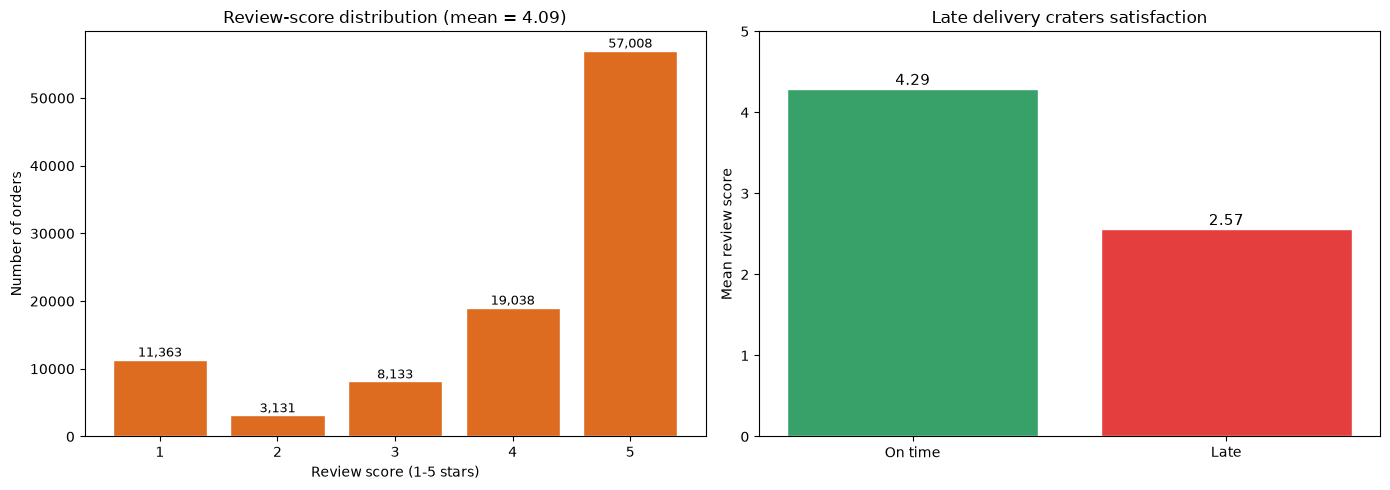

review_score
1.0    11363
2.0     3131
3.0     8133
4.0    19038
5.0    57008


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["review_score"].value_counts().sort_index()
axes[0].bar(counts.index.astype(int).astype(str), counts.values,
            color="#dd6b20", edgecolor="white")
for x, v in zip(counts.index.astype(int).astype(str), counts.values):
    axes[0].text(x, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
axes[0].set(xlabel="Review score (1-5 stars)", ylabel="Number of orders",
            title=f"Review-score distribution (mean = {df['review_score'].mean():.2f})")

# Mean review score split by on-time vs late — the core product signal.
by_late = delivered.groupby("is_late")["review_score"].mean()
axes[1].bar(["On time", "Late"], [by_late.get(False), by_late.get(True)],
            color=["#38a169", "#e53e3e"], edgecolor="white")
for i, v in enumerate([by_late.get(False), by_late.get(True)]):
    axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=11)
axes[1].set(ylim=(0, 5), ylabel="Mean review score",
            title="Late delivery craters satisfaction")
plt.tight_layout()
plt.savefig(FIG / "review_score_distribution.png", dpi=110, bbox_inches="tight")
plt.show()
print(counts.to_string())

## 9. Findings (Phase 1)

- **Scale & join.** 99,441 orders join cleanly to one row each across 8 source
  tables; no fan-out. ~96.5k are `delivered`.
- **Estimates are padded.** Median *actual* delivery is ~10 days vs a ~23-day
  *estimate* — Olist quotes conservatively, so most orders land comfortably early.
- **Late rate ≈ 8%** of delivered orders arrive after the estimate.
- **Lateness destroys satisfaction.** Mean review score is ~4.3 for on-time
  orders but drops to ~2.6 for late ones — the strongest signal for the Phase 3
  delay / satisfaction models.
- **Reviews skew positive** (mean ≈ 4.09; ~57% are 5★, but a hard ~11% 1★ tail).
- **Missingness is structural, not corruption:** absent delivery dates (~3%)
  correspond to undelivered/canceled orders; ~0.8% of orders have no review.

See `docs/data_dictionary.md` for every table and column.
